# Stage 05 — Evaluation: Baseline vs. Augmented

Loads the **`'baseline'`** run (Stage 03, price-only features) and the **`'augmented'`** run (Stage 04, price + `chart_patterns` flags), both already trained and saved to the Shared Drive, and compares them head-to-head on the held-out test period -- **without retraining either model**.

Compares:
- Test RMSE and directional (up/down) accuracy, side by side
- Predicted vs. actual returns over the test period, for each model
- Per-example error, to check whether the augmented model's edge (if any) is statistically distinguishable from noise on this test set

**A note on interpretation:** both runs were tuned independently (different trials sampled different hyperparameters for each), so a difference in test RMSE reflects the combination of *feature set + whatever configuration Optuna happened to find best for it* -- not a perfectly isolated ablation of the pattern features alone. That is the standard caveat for comparing two independently-tuned pipelines, not a flaw specific to this setup.


## Environment setup (Google Colab)

Mounts the Drive and clones the repo via the `GITHUB_TOKEN` secret. No tuning happens in this notebook, so `ray`/`optuna` aren't needed here, but `requirements.txt` installs the full set regardless -- inexpensive, and keeps every notebook's setup cell identical.


In [ ]:
import os
import sys

from google.colab import drive, userdata

drive.mount('/content/drive')

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = 'jesseingraham'
REPO_NAME = 'comp-653-stock-prediction-i'
REPO_PATH = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_PATH):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git

os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

!pip install -r requirements.txt


## Imports & configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from config import DRIVE_MODELS_PATH
from src.models.rnn_forecaster import RNNForecaster
from src.utils import artifacts, plotting


## 1. Load both saved runs

`artifacts.find_latest_run` + `artifacts.load_run` rebuild each model from its saved `state_dict` and reload its manifest, scaler, tuning trials, learning curves, and frozen test predictions -- exactly as `save_run` wrote them at the end of Stage 03 and Stage 04. Nothing here re-trains anything.


In [4]:
baseline = artifacts.load_run(artifacts.find_latest_run('baseline'))
augmented = artifacts.load_run(artifacts.find_latest_run('augmented'))

for label, run in [('baseline', baseline), ('augmented', augmented)]:
    prov = run['manifest'].get('provenance', {})
    print(f"{label:>9} | timestamp={run['manifest'].get('timestamp')} "
          f"| num_features={prov.get('num_features')} "
          f"| n_test={prov.get('n_test')} "
          f"| dataset={prov.get('dataset_file')}")


 baseline | timestamp=20260809_060531 | num_features=6 | n_test=742 | dataset=sp500_windows_baseline.npz
augmented | timestamp=20260814_202532 | num_features=11 | n_test=742 | dataset=sp500_windows_augmented.npz


## 2. Headline metrics, side by side

Straight from each run's `manifest['metrics']`, written by `save_run` at the end of Stage 03/04 -- test RMSE, directional accuracy, and the tuning objective (`best_val_rmse`) that Optuna optimized during walk-forward CV.


In [5]:
summary = pd.DataFrame(
    [baseline['manifest']['metrics'], augmented['manifest']['metrics']],
    index=['baseline', 'augmented'],
)
summary['rmse_delta_vs_baseline'] = summary['test_rmse'] - summary.loc['baseline', 'test_rmse']
summary['directional_acc_delta_vs_baseline'] = (
    summary['test_directional_accuracy'] - summary.loc['baseline', 'test_directional_accuracy']
)
summary.round(6)


,test_rmse,test_directional_accuracy,best_val_rmse,rmse_delta_vs_baseline,directional_acc_delta_vs_baseline
baseline,0.009626,0.555256,0.010813,0.000000,0.000000
augmented,0.009664,0.444744,0.010810,0.000038,-0.110512


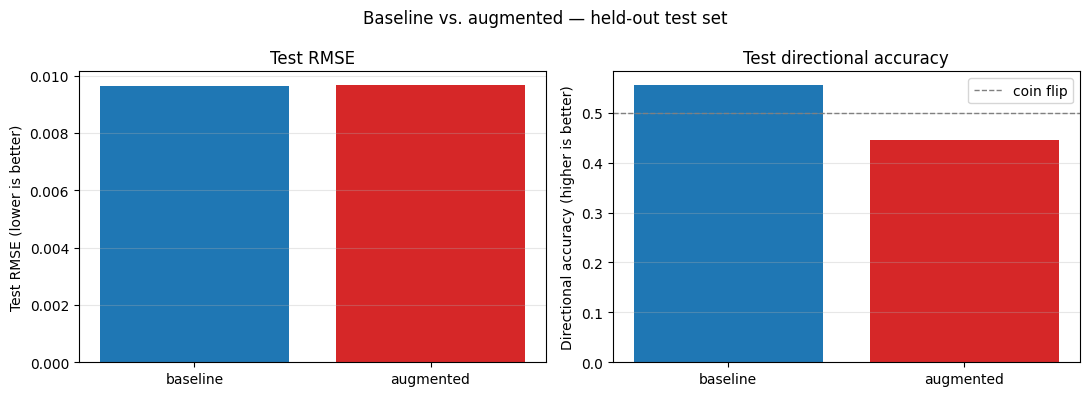

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#1f77b4', '#d62728']
labels = ['baseline', 'augmented']

axes[0].bar(labels, summary['test_rmse'], color=colors)
axes[0].set_ylabel('Test RMSE (lower is better)')
axes[0].set_title('Test RMSE')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(labels, summary['test_directional_accuracy'], color=colors)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='coin flip')
axes[1].set_ylabel('Directional accuracy (higher is better)')
axes[1].set_title('Test directional accuracy')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('Baseline vs. augmented — held-out test set')
fig.tight_layout()
plt.show()


## 3. Predictions vs. actual, over the test period

Each model's frozen test-set predictions (`test_predictions.csv`, written by `save_run`) plotted against actual log returns. Same test window for both, since Stage 02 builds both feature sets from the same cleaned data with the same `TEST_FRAC`, and the pattern columns are dense (no NaNs), so they don't change which windows survive `dropna`.


In [7]:
baseline_preds = baseline['predictions']
augmented_preds = augmented['predictions']

assert len(baseline_preds) == len(augmented_preds), (
    "Baseline and augmented test sets have different lengths "
    f"({len(baseline_preds)} vs {len(augmented_preds)}) -- they should share the "
    "same test window. Re-check that both were built from the same TEST_FRAC "
    "in Stage 02/03/04 before trusting the comparison below."
)

baseline_dates = pd.to_datetime(baseline_preds['date']) if 'date' in baseline_preds else None


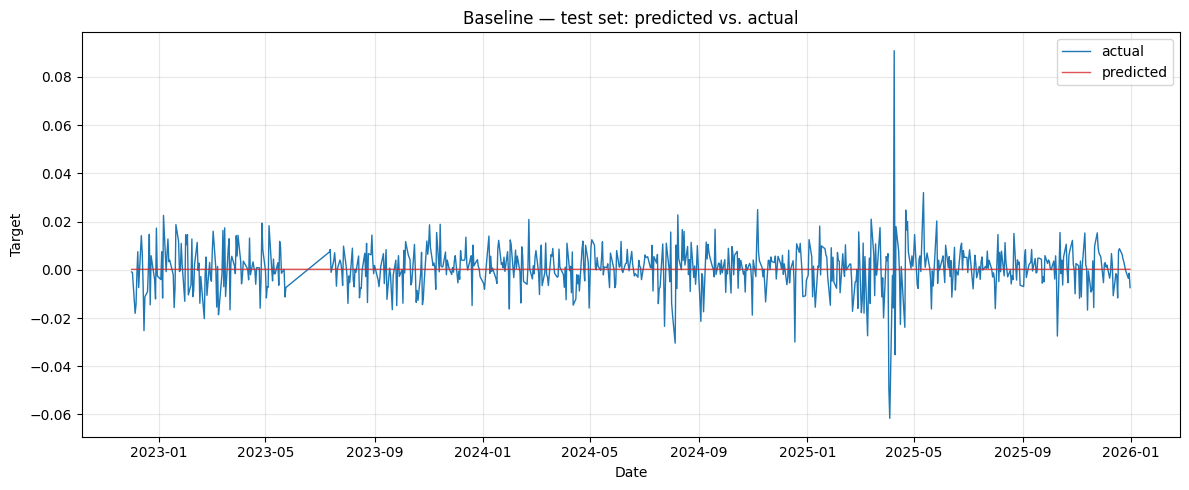

In [8]:
fig = plotting.plot_predictions_vs_actual(
    baseline_preds['target_0'], baseline_preds['pred_0'],
    index=baseline_dates, title='Baseline — test set: predicted vs. actual',
)
plt.show()


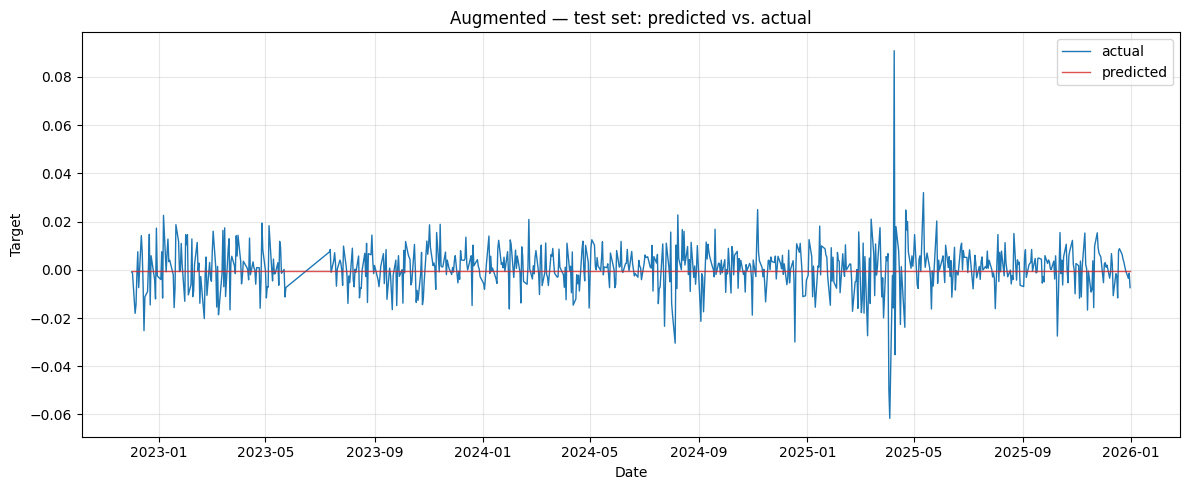

In [9]:
fig = plotting.plot_predictions_vs_actual(
    augmented_preds['target_0'], augmented_preds['pred_0'],
    index=baseline_dates, title='Augmented — test set: predicted vs. actual',
)
plt.show()


## 4. Is the difference in error real, or noise?

A bar-chart RMSE gap alone can't say whether the augmented model is *actually* better or just landed on a slightly luckier test period / tuning draw. Since both models are scored on the same test examples, a **paired** comparison is the right tool: for each test date, take each model's squared error and run a paired t-test on the two error series.

- **p < 0.05:** the two models' errors differ by more than would be expected from chance alone on this test set.
- **p ≥ 0.05:** not enough evidence in this test set to say one model's errors are systematically different from the other's -- the RMSE gap above could plausibly be noise.

This is a check on statistical significance, not practical significance -- a statistically real but tiny RMSE difference may not be worth the extra complexity of the pattern features, and that's a judgment call for the write-up, not something a p-value settles alone.


In [10]:
baseline_sq_err = (baseline_preds['target_0'] - baseline_preds['pred_0']) ** 2
augmented_sq_err = (augmented_preds['target_0'] - augmented_preds['pred_0']) ** 2

t_stat, p_value = stats.ttest_rel(baseline_sq_err, augmented_sq_err)

print(f"Mean squared error  — baseline: {baseline_sq_err.mean():.7f}  |  "
      f"augmented: {augmented_sq_err.mean():.7f}")
print(f"Paired t-test on squared errors: t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    better = 'augmented' if augmented_sq_err.mean() < baseline_sq_err.mean() else 'baseline'
    print(f"-> Significant at p<0.05: {better}'s errors are systematically smaller on this test set.")
else:
    print("-> Not significant at p<0.05: can't distinguish the two models' errors from noise here.")


Mean squared error  — baseline: 0.0000927  |  augmented: 0.0000934
Paired t-test on squared errors: t=-1.888, p=0.0595
-> Not significant at p<0.05: can't distinguish the two models' errors from noise here.


## 5. Hyperparameters each model settled on

Since each was tuned independently, it's worth checking *what* Optuna found best for each feature set -- similar configs would suggest the pattern features didn't meaningfully change the optimization landscape; very different configs suggest they did.


In [11]:
config_compare = pd.DataFrame(
    [baseline['config'], augmented['config']], index=['baseline', 'augmented']
)
config_compare


,hidden_size,num_layers,dropout,lr,batch_size,weight_decay
baseline,128,3,0.410497,0.000156,128,0.000025
augmented,128,3,0.010384,0.000843,128,0.000845


## Summary

The **baseline** (price-only) and **pattern-augmented** `RNNForecaster` runs have been compared head-to-head on the same held-out test period, without retraining either: headline metrics, prediction plots, and a paired significance test on per-example squared error.

**Reading the result:** check the RMSE/directional-accuracy deltas in Section 2 alongside the paired t-test in Section 4 together -- a numeric edge for the augmented model only supports the "chart patterns help" conclusion if it's also statistically distinguishable from noise on this test set. If the two models are close in Section 2 *and* the t-test in Section 4 isn't significant, the honest conclusion is that this test period doesn't provide clear evidence either way, which is itself a legitimate finding to report.
